In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

In [2]:
colors = ['#7030A0', '#FC7F02', '#C60084', '#8A30CF', '#FDAD5D','#864FB0', '#B28ECC']

plt.rcParams['axes.prop_cycle'] = plt.cycler(color=colors)

In [3]:
file_path = r"D:\учеба\аналитик\т-банк отбор\кейс\dano_dataset_travel.csv"
df = pd.read_csv(file_path, sep=';')

In [4]:
print(f"Размер датасета: {df.shape}")
print(f"Количество строк: {df.shape[0]}")
print(f"Количество столбцов: {df.shape[1]}\n")

Размер датасета: (835938, 56)
Количество строк: 835938
Количество столбцов: 56



In [5]:
print("Информация о типах данных:")
print(df.info())

Информация о типах данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 835938 entries, 0 to 835937
Data columns (total 56 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   order_online_payment_flg     786885 non-null  object 
 1   account_rk                   835938 non-null  object 
 2   client_rk                    835938 non-null  object 
 3   order_rk                     835938 non-null  object 
 4   loyalty_program_type_nm      754957 non-null  object 
 5   bundle_nm                    588049 non-null  object 
 6   order_type_cd                786885 non-null  object 
 7   order_status_cd              779514 non-null  object 
 8   party_first_order_dt         786885 non-null  object 
 9   party_first_order_type_dt    786767 non-null  object 
 10  free_cancel_booking_dttm     75600 non-null   object 
 11  created_dttm                 786885 non-null  object 
 12  cancel_dttm                  0 

**Большинство переменных имеют тип данных object, хотя тут много численных значений, позже это исправим.**

In [6]:
print('Первые 5 строк данных:')
print(df.head())

Первые 5 строк данных:
  order_online_payment_flg                                         account_rk  \
0                      1,0  209c833731e84d21b5b7e673e0fb848749b9e7d29cda64...   
1                      1,0  2bbcde706bead3731f2dc8dfbeefb4e12b42ac63e3d8ba...   
2                      1,0  a82919af3a5a1869f9becdcffa5c7d303d105797ce45b8...   
3                      1,0  9b2d5b4678781e53038e91ea5324530a03f27dc1d0e5f6...   
4                      1,0  3133e7ae6698dcda9754d6a8b449782320260ff1259547...   

                                           client_rk  \
0  f4959ffb27271192727050953ecb27a8a8a38af413f3d8...   
1  7025587bc277176246bc44dff396036552a41d5a92d6aa...   
2  0368b36ccd204d631305233a1f952bc5fb0e3fd9f690fa...   
3  1346344779d7bd788d03ec2ad1908daf71c6358aca47f1...   
4  1a2a4351a96099f9e49bbe2fc7236d41ac63b444176058...   

                                            order_rk loyalty_program_type_nm  \
0  fe1c6ce13774d102c655df4c01d54c34d495ef3d4c7e63...                   Br

**Посмотрим на каждый столбец, т.к. многие были пропущены:**

In [7]:
#(закомментировано, чтобы вывод не занимал много места)
# for column in df.columns:
#     print(df[column].head())

## Анализ пропущенных значений:

In [8]:
nan_data = df.isnull().sum()
nan_percent = (df.isnull().sum() / len(df)) * 100

nan_data_info = pd.DataFrame({
    'Переменная': df.columns,
    'Пропущено': nan_data,
    'Процент пропусков': nan_percent
})

nan_data_info = nan_data_info[nan_data_info['Пропущено'] > 0].sort_values('Процент пропусков', ascending=False)

In [9]:
print("Колонки с пропущенными значениями:")
print(nan_data_info)

Колонки с пропущенными значениями:
                                              Переменная  Пропущено  \
cancel_dttm                                  cancel_dttm     835938   
call_contact_1m_flg                  call_contact_1m_flg     835667   
call_contact_6m_flg                  call_contact_6m_flg     835667   
call_contact_3m_flg                  call_contact_3m_flg     835667   
good_email_address_flg            good_email_address_flg     816140   
last_email_send_dt                    last_email_send_dt     816140   
bad_email_address_flg              bad_email_address_flg     816140   
bounce_cd                                      bounce_cd     796263   
free_cancel_booking_dttm        free_cancel_booking_dttm     760338   
hotel_city                                    hotel_city     673690   
hotel_country                              hotel_country     673690   
book_end_dttm                              book_end_dttm     664390   
education_level_cd                    educ

**Удалим колонки, где более 90% пропусков:**

In [10]:
cols_to_drop = nan_data_info[nan_data_info['Процент пропусков'] > 90]['Переменная'].tolist()
print("Столбцы, в которых > 90% значений пропущены:")
cols_to_drop

Столбцы, в которых > 90% значений пропущены:


['cancel_dttm',
 'call_contact_1m_flg',
 'call_contact_6m_flg',
 'call_contact_3m_flg',
 'good_email_address_flg',
 'last_email_send_dt',
 'bad_email_address_flg',
 'bounce_cd',
 'free_cancel_booking_dttm']

**Самым важным из этих полей мне кажется cancel_dttm. Возможно, эти данные не были выгружены.**

In [11]:
df = df.drop(columns=cols_to_drop)

**Без возраста только 1 строка, просто удалим ее:**

In [12]:
df = df.dropna(subset=['age'])

In [13]:
df.shape

(835937, 47)

## Преобразование некоторых числовых переменных и столбцов с датами:

In [14]:
num_cols = ['promo_code_discount_amt', 'loyalty_accrual_rub_amt', 'nominal_price_eur_amt', 'nominal_price_rub_amt', 'order_item_cnt',
            'month_beginning_balance_rub', 'monthly_income_amt', 'last_sms_success_flg', 'children_cnt', 'age']
int_cols = []
for col in num_cols:
    df[col] = (
        df[col]
        .str.replace(',', '.', regex=False) 
        .str.replace(' ', '', regex=False)  
        .replace('', np.nan)            
    )
    
    df[col] = pd.to_numeric(df[col])

**Вообще, нецелые значения в колонках не были замечены, но теоретически цена, сумма, скидка и т.д. обычно вещественны, поэтому было принято решение преобразовать их к типу float.**

In [15]:
date_cols = ['party_first_order_dt', 'party_first_order_type_dt', 'created_dttm', 'book_start_dttm', 
             'local_book_start_dttm', 'book_end_dttm', 'last_sms_dt', 'last_session_dttm']
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 835937 entries, 0 to 835937
Data columns (total 47 columns):
 #   Column                       Non-Null Count   Dtype         
---  ------                       --------------   -----         
 0   order_online_payment_flg     786885 non-null  object        
 1   account_rk                   835937 non-null  object        
 2   client_rk                    835937 non-null  object        
 3   order_rk                     835937 non-null  object        
 4   loyalty_program_type_nm      754957 non-null  object        
 5   bundle_nm                    588049 non-null  object        
 6   order_type_cd                786885 non-null  object        
 7   order_status_cd              779514 non-null  object        
 8   party_first_order_dt         786885 non-null  datetime64[ns]
 9   party_first_order_type_dt    786767 non-null  datetime64[ns]
 10  created_dttm                 786885 non-null  datetime64[ns]
 11  book_start_dttm              78

## Анализ переменных:

Распределение типов заказов:
AIR: 615337 (78.2%)
HOT: 171548 (21.8%)


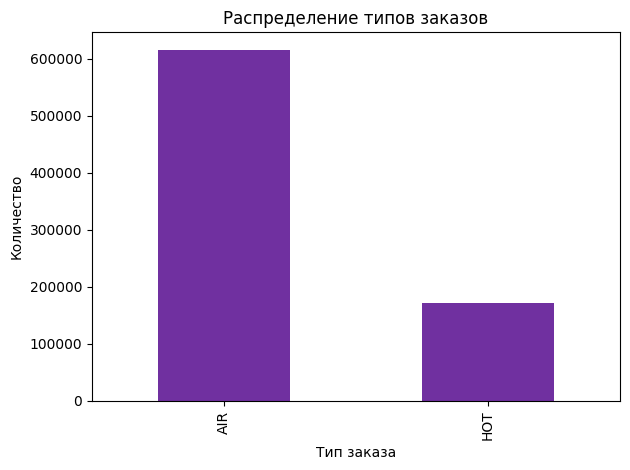

In [107]:
print("Распределение типов заказов:")
order_counts = df['order_type_cd'].value_counts()
total = order_counts.sum()

for order_type, count in order_counts.items():
    percentage = count / total * 100
    print(f"{order_type}: {count} ({percentage:.1f}%)")
    
plt.figure()
df['order_type_cd'].value_counts().plot(kind='bar')
plt.title('Распределение типов заказов')
plt.xlabel('Тип заказа')
plt.ylabel('Количество')
plt.tight_layout()
plt.show()

**Пользователи бронируют авиабилеты значительно чаще, чем отели.**

In [110]:
print("\nРаспределение статусов заказов:")
print(df['order_status_cd'].value_counts())


Распределение статусов заказов:
order_status_cd
SUC    759950
PRC     18467
ERR       650
NSH       304
CNC        84
REJ        58
BRN         1
Name: count, dtype: int64


**В описании датасета не была указана расшифровка данных статусов. Скорее всего данные показатели означают следующее:**

**SUC** - заказ успешно завершен

**PRC** - в процессе обработки

**ERR** - ошибка при выполнении

**NSH** - клиент не явился

**CNC** - заказ отменен клиентом

**REJ** - отклонен системой/банком

Большинство заказов успешно завершены. Но достаточно большое количество заказов в статусе обработки, хоть в процентном соотношении оно составляет всего 2.4%. Нужно проанализировать, какой процент таких заказов переходит в статус SUC, и выяснить, в чем причина такого количества заказов в процессе обработки.

Я вижу **2 возможные причины:**

**1. Проблемы на одном из технических этапов обработки. Возможно, длительное ожидание подтверждения бронирования от партнеров.**

В таком случае могут быть следующие решения проблемы: автоматический подбор альтернативных вариантов по истечении определенного времени обработки и налаживание процессов коммуникации с партнерами.

**2. Более вероятная причина - клиент начал бронирование, но не завершил его.**

Для решения этой проблемы можно улучшить рассылку push-уведомлений с напоминаниями. Затем предлагать альтернативные варианты и скидки, промокоды.

In [20]:
print("\nРаспределение программ лояльности:")
print(df['loyalty_program_type_nm'].value_counts())


Распределение программ лояльности:
loyalty_program_type_nm
Tinkoff Black                     289081
Tinkoff Black Premium             189005
All Airlines                      143114
Bravo                              41428
All Airlines Premium Кредитный     28634
All Airlines Premium               16277
AllAirLinesDebit                   14824
Tinkoff Black Private               6994
Tinkoff Platinum                    6154
Tinkoff Platinum Premium            5737
Tinkoff Drive                       2992
Tinkoff Black Shared                2615
Tinkoff Drive Debit                 2327
S7                                  1591
All Airlines Private Кредитный      1390
S7Debit                              533
S7 Tinkoff Premium                   450
S7 Tinkoff Premium Кредитный         405
Tinkoff Platinum Private             387
WargamingTanksDebit                  266
All Games Debit                      110
All Games                            100
Lukoil                                

**Для переменных с большим количеством значений будем смотреть только первые 15-20 значений.**


Распределение стран отелей:
hotel_country
Россия        120729
Турция          7511
Таиланд         5611
ОАЭ             3903
Италия          2002
Китай           1912
Япония          1787
Грузия          1519
Казахстан       1322
Индонезия       1204
Армения         1139
Узбекистан      1095
Франция         1059
Вьетнам          832
Беларусь         807
Другие          9816
Name: count, dtype: int64


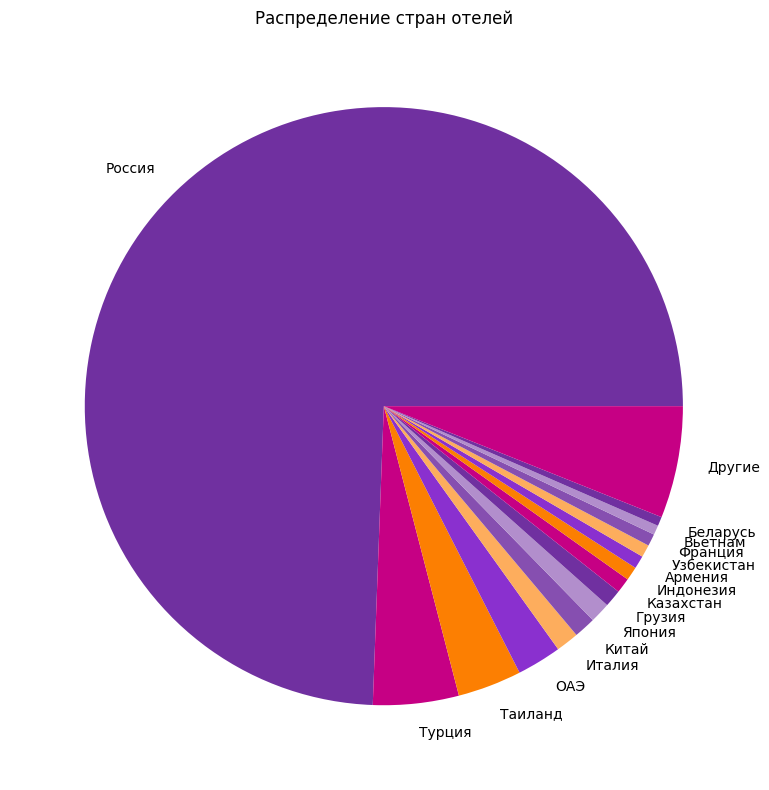

In [119]:
print("\nРаспределение стран отелей:")
country_counts = df['hotel_country'].value_counts()

top_countries = country_counts.head(15)  
others_sum = country_counts[15:].sum()  

pie_data = top_countries.copy()
pie_data['Другие'] = others_sum

print(pie_data)

plt.figure(figsize=(10, 8))
plt.pie(pie_data.values, labels=pie_data.index, )
plt.title('Распределение стран отелей')
plt.tight_layout()
plt.show()

**Самая популярная страна - Россия, что очевидно. Из зарубежных направлений спрос больше всего на отели в Турции, Таиланде и ОАЭ.**

Можно попробовать сделать сегментированные рассылки и предлагать клиентам новые варианты в других городах/странах в зависимости от их предпочтений.

In [35]:
print("\nРаспределение городов отелей:")
hotel_city_counts = df['hotel_city'].value_counts().head(25)
total = df['hotel_city'].value_counts().sum()

result_df = pd.DataFrame({
    'Количество': hotel_city_counts,
    'Процент': (hotel_city_counts / total * 100).round(1)
})

print(result_df)


Распределение городов отелей:
                 Количество  Процент
hotel_city                          
Москва                22624     13.9
Санкт-Петербург       13881      8.6
Сочи                   6098      3.8
Казань                 3675      2.3
Стамбул                3379      2.1
Дубай                  3111      1.9
Екатеринбург           2447      1.5
Краснодар              2341      1.4
Эсто-Садок             2301      1.4
Нижний Новгород        2150      1.3
Ростов-на-Дону         1827      1.1
Калининград            1683      1.0
Новосибирск            1677      1.0
Самара                 1526      0.9
Бангкок                1391      0.9
Воронеж                1338      0.8
Красная Поляна         1312      0.8
Волгоград              1306      0.8
Владивосток            1255      0.8
Иркутск                1250      0.8
Уфа                    1096      0.7
Ереван                 1070      0.7
Пхукет                 1052      0.6
Анталья                1042      0.6
Тбилиси

**Чаще всего люди останавливаются в Москве, Санкт-Петербурге и Сочи. Самые популярные города за границей - Стамбул и Дубай.**

In [139]:
print("\nРаспределение городов вылета для заказов авиабилетов:")
dep_city_counts = df['avia_dep_city'].value_counts().head(15)
total = df['avia_dep_city'].value_counts().sum()

result_df = pd.DataFrame({
    'Количество': dep_city_counts,
    'Процент': (dep_city_counts / total * 100).round(1)
})

print(result_df)


Распределение городов вылета для заказов авиабилетов:
                  Количество  Процент
avia_dep_city                        
Москва                202016     32.8
Санкт-Петербург        55202      9.0
Сочи (Адлер)           32054      5.2
Екатеринбург           24003      3.9
Минеральные Воды       14854      2.4
Казань                 14110      2.3
Уфа                    12722      2.1
Стамбул                11285      1.8
Новосибирск            10404      1.7
Самара                 10246      1.7
Калининград            10089      1.6
Красноярск              8845      1.4
Ереван                  8718      1.4
Душанбе                 8205      1.3
Махачкала               7803      1.3


In [129]:
print("\nРаспределение городов прилета:")
arr_city_counts = df['avia_arr_city'].value_counts().head(15)
total = df['avia_arr_city'].value_counts().sum()

result_df = pd.DataFrame({
    'Количество': arr_city_counts,
    'Процент': (arr_city_counts / total * 100).round(1)
})

print(result_df)


Распределение городов прилета:
                  Количество  Процент
avia_arr_city                        
Москва                188962     30.7
Санкт-Петербург        54341      8.8
Сочи (Адлер)           31048      5.0
Екатеринбург           22843      3.7
Минеральные Воды       14364      2.3
Казань                 13547      2.2
Душанбе                13524      2.2
Уфа                    12480      2.0
Стамбул                11158      1.8
Самара                  9933      1.6
Ош                      9923      1.6
Новосибирск             9901      1.6
Калининград             9726      1.6
Ереван                  8787      1.4
Красноярск              8222      1.3


Москва сильно доминирует, что логично, т.к. она является крупным пересадочным узлом.

Неожиданным для меня городом в этом списке оказался Ош. Следует изучить это направление.

**Также можно сделать вывод, что обратные билеты покупают реже.**

Можно подумать над улучшением условий для покупки билетов туда-обратно. Идеи:

1. Делать рассылку с предложением купить обратный билет. 
2. Более выгодные условия: гарантия, что цена ниже, чем при покупке билетов по отдельности; возможность поменять обратный билет на другую дату; более лояльная система отмены обратного билета.
3. Устроить "челлендж": после совершения 3 поездок с обратными билетами предлагать какие-либо бонусы - скидки, промокоды.

In [38]:
print("\nРаспределение размеров скидки по промокоду:")
print(df['promo_code_discount_amt'].value_counts().head(15))


Распределение размеров скидки по промокоду:
promo_code_discount_amt
0.0        608182
335.0        2608
100.0        2271
201.0         822
670.0         756
469.0         536
1340.0        453
1005.0         92
2010.0         50
2680.0         19
3350.0         15
268.0          10
50.0            4
33500.0         3
168.0           3
Name: count, dtype: int64


**Посмотрим, влияет ли наличие промокодов на средний чек:**

Количество покупок с промокодами: 7718
Количество покупок без промокодов: 608182
Доля пользователей с промокодами: 0.92%


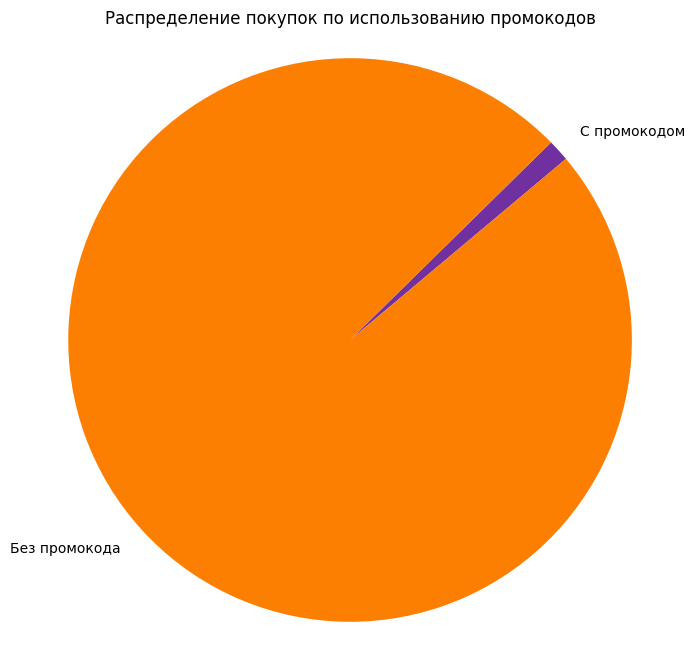


Сравнение средних чеков:
С промокодом: 13845.05 руб.
Без промокода: 16096.16 руб.


In [137]:
promo_customers = df[df['promo_code_discount_amt'] > 0]
without_promo_customers = df[df['promo_code_discount_amt'] == 0]
    
print(f"Количество покупок с промокодами: {len(promo_customers)}")
print(f"Количество покупок без промокодов: {len(without_promo_customers)}")
print(f"Доля пользователей с промокодами: {len(promo_customers)/len(df)*100:.2f}%")

labels = ['С промокодом', 'Без промокода']
sizes = [len(promo_customers), len(without_promo_customers)]

plt.figure(figsize=(8, 8))
plt.pie(sizes, labels=labels, colors=colors, startangle=40)
plt.title('Распределение покупок по использованию промокодов')
plt.axis('equal')
plt.show()
    
if 'nominal_price_rub_amt' in df.columns:
    print(f"\nСравнение средних чеков:")
    print(f"С промокодом: {promo_customers['nominal_price_rub_amt'].mean():.2f} руб.")
    print(f"Без промокода: {without_promo_customers['nominal_price_rub_amt'].mean():.2f} руб.")

Хотелось ожидать другой результат, что промокоды стимулируют пользователей на более крупные покупки.

Тем не менее, **доля заказов с промокодами крайне мала**, чтобы делать такие выводы.

Вероятно, клиенты слабо проинформированы о наличии промокодов, эту проблему следует проанализировать дополнительно. 

In [20]:
df['nominal_price_rub_amt'].describe()

count    7.868850e+05
mean     1.517810e+04
std      2.402879e+04
min      1.000000e+00
25%      5.090000e+03
50%      9.342000e+03
75%      1.652700e+04
max      2.025808e+06
Name: nominal_price_rub_amt, dtype: float64

**Посмотрим распределение количества покупок по ценовым категориям:**

nominal_price_rub_amt
0-2к       23969
2-4к      108352
4-6к      110231
6-8к       93761
8-10к      82655
10-12к     71187
12-14к     51443
14-16к     39741
16-18к     32366
18-20к     25105
20-22к     19781
22-24к     16800
24-26к     13075
26-28к     10608
28-30к      8686
30-32к      7671
32-34к      6410
34-36к      5809
36-38к      5108
38-40к      4636
40-42к      3924
42-44к      3536
44-46к      3266
>46к       38765
Name: count, dtype: int64


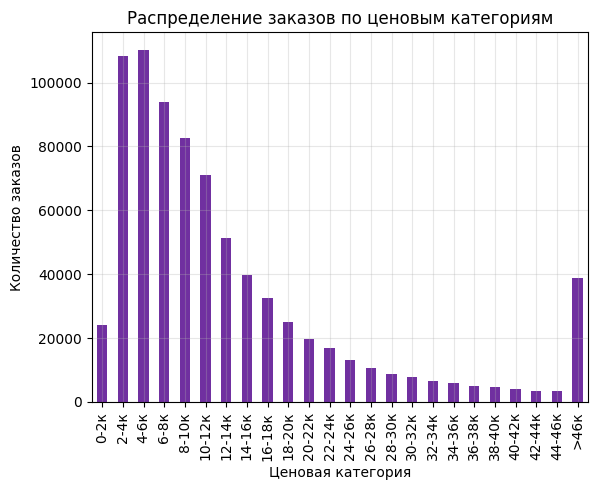

In [113]:
max_pr = df['nominal_price_rub_amt'].quantile(0.95) # не учитываем выбросы
step = 2000

bins = list(range(0, int(max_pr) + step, step))
bins.append(float('inf'))

labels = []
for i in range(len(bins)-1):
    if bins[i+1] == float('inf'):
        labels.append(f">{bins[i]//1000}к") 
    else:
        labels.append(f"{bins[i]//1000}-{bins[i+1]//1000}к")

price_distr = pd.cut(df['nominal_price_rub_amt'], bins=bins, labels=labels, right=False).value_counts().sort_index()
print(price_distr)

plt.figure()
price_distr.plot(kind='bar')
plt.title('Распределение заказов по ценовым категориям')
plt.xlabel('Ценовая категория')
plt.ylabel('Количество заказов')
plt.grid(True, alpha=0.3)

Средний ценовой сегмент явно доминирует (50% всех покупок), это логично. Но также достаточно велико количество заказов с высокой стоимостью. Можно развить это направление: предлагать покупателям эксклюзивные услуги, сделать годовую премиум-подписку.

In [42]:
print("Статистики возраста:")
print(df['age'].describe())

Статистики возраста:
count    835937.000000
mean         36.073155
std           9.370449
min          14.000000
25%          29.000000
50%          35.000000
75%          41.000000
max          98.000000
Name: age, dtype: float64


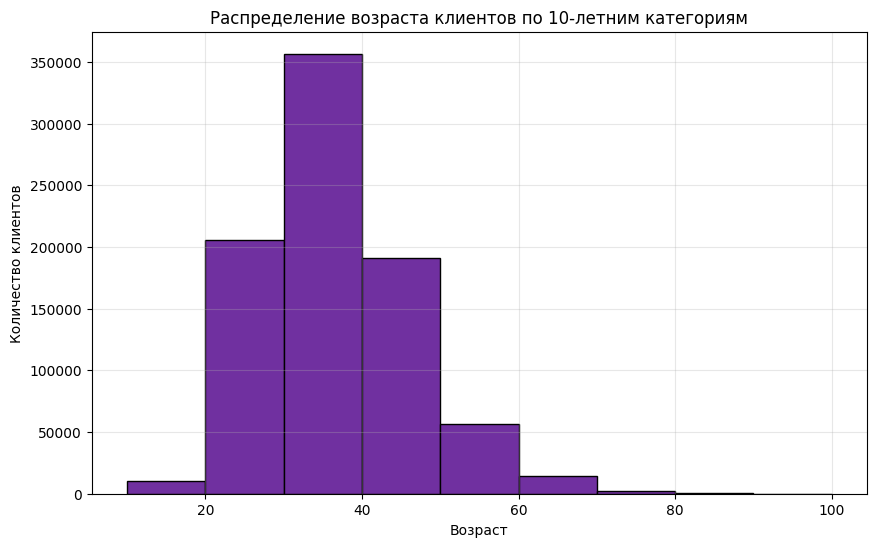

In [114]:
plt.figure(figsize=(10, 6))

min_age = df['age'].min()
max_age = df['age'].max()
bins = list(range(int(min_age)//10*10, int(max_age)//10*10 + 11, 10))

plt.hist(df['age'], bins=bins, edgecolor='black')
plt.title('Распределение возраста клиентов по 10-летним категориям')
plt.xlabel('Возраст')
plt.ylabel('Количество клиентов')
plt.grid(True, alpha=0.3)
plt.show()

Наблюдается широкий охват возрастных групп: от 14 до 98 лет.

Средний возраст - 36 лет.

75% клиентов младше 41 года.

Возраст основной аудитории - 30-40 лет, что логично: в этом возрасте обычно максимальная платежеспособность, также зачастую высокие расходы на семейные поездки.

Распределение количества позиций в заказах:
1.0: 441300 (71.7%)
2.0: 127204 (20.7%)
3.0: 30585 (5.0%)
4.0: 10887 (1.8%)
5.0: 3275 (0.5%)
6.0: 1136 (0.2%)
8.0: 511 (0.1%)
7.0: 411 (0.1%)
9.0: 28 (0.0%)


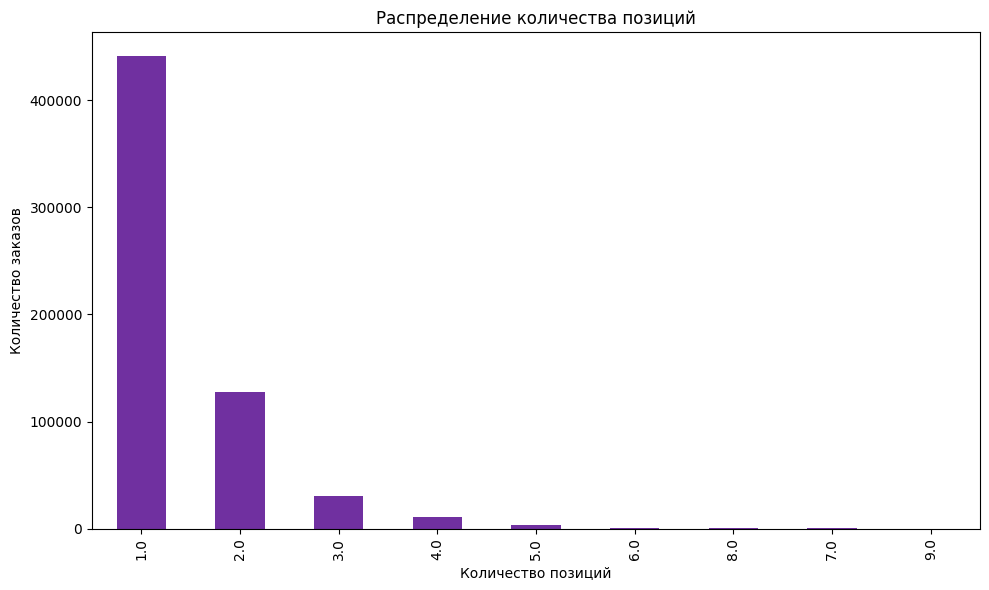

In [120]:
print("Распределение количества позиций в заказах:")
order_counts = df['order_item_cnt'].value_counts()
total = order_counts.sum()

for order_cnts, count in order_counts.items():
    percentage = count / total * 100
    print(f"{order_cnts}: {count} ({percentage:.1f}%)")
    
plt.figure(figsize=(10, 6))
order_counts.plot(kind='bar')
plt.title('Распределение количества позиций')
plt.xlabel('Количество позиций')
plt.ylabel('Количество заказов')
plt.tight_layout()
plt.show()

**71.7% всех заказов - одиночные покупки.**

Чтобы увеличить количество комбинированных покупок, можно создать бонусы и скидки. Например, бесплатная страховка или выбор места в самолете при бронировании билета + отеля; скидка на корзину, состоящую из 2 и более позиций.

['(8.0%)', '(20.1%)', '(22.1%)', '(21.3%)', '(15.0%)', '(9.2%)', '(3.5%)', '(0.7%)']


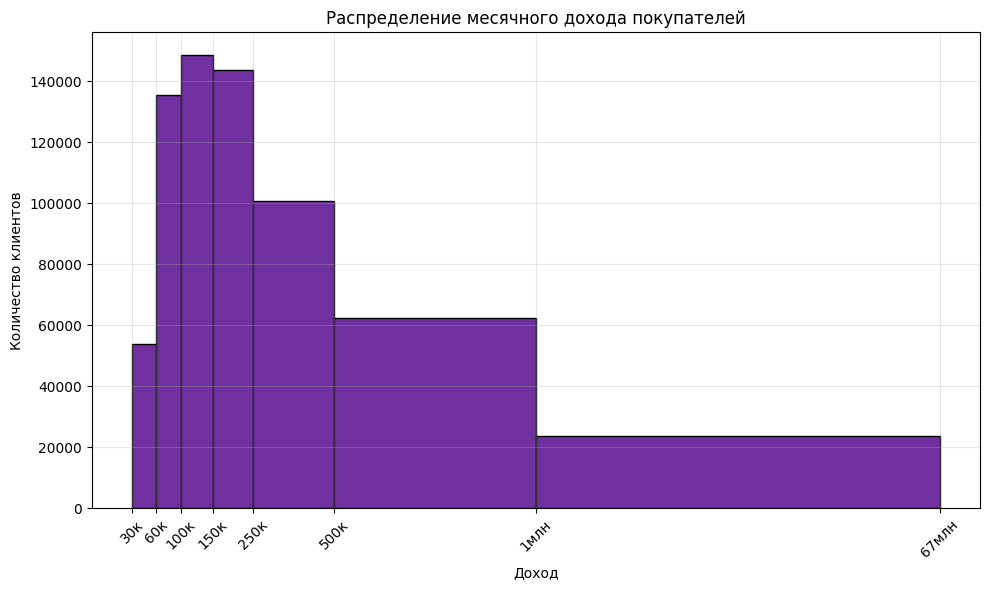

In [142]:
max_income = df['monthly_income_amt'].max()
bins = [0, 30000, 60000, 100000, 150000, 250000, 500000, 1000000, float('inf')]
labels = labels = ['30к', '60к', '100к', '150к', '250к', '500к', '1млн', f'{int(max_income//1000000)}млн']

plt.figure(figsize=(10, 6))
counts, bins, patches = plt.hist(df['monthly_income_amt'], bins=bins, edgecolor='black')
total = len(df['monthly_income_amt'].dropna())
percentages = [f'({count/total*100:.1f}%)' for count in counts]
print(percentages)

plt.title('Распределение месячного дохода покупателей')
plt.xlabel('Доход')
plt.ylabel('Количество клиентов')
plt.xticks(bins[:-1], labels, rotation=45) 
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Основная часть значений среднего дохода покупателей расположена в интервале от 60 до 250 тысяч рублей.**

Распределение количества заказов в зависимости от числа детей у клиентов:
0.0: 687450 (95.5%)
1.0: 17261 (2.4%)
2.0: 11679 (1.6%)
3.0: 2930 (0.4%)
4.0: 284 (0.0%)
5.0: 69 (0.0%)
6.0: 18 (0.0%)
8.0: 7 (0.0%)


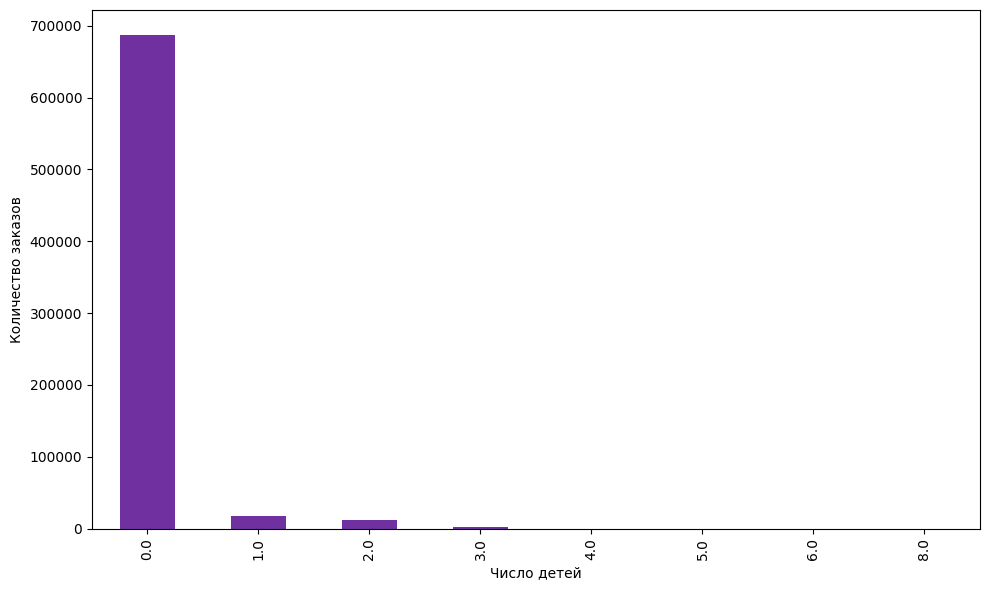

In [19]:
print("Распределение количества заказов в зависимости от числа детей у клиентов:")
children_cnt = df['children_cnt'].value_counts()
total = children_cnt.sum()

for order_type, count in children_cnt.items():
    percentage = count / total * 100
    print(f"{order_type}: {count} ({percentage:.1f}%)")
    
plt.figure(figsize=(10, 6))
children_cnt.plot(kind='bar')
plt.xlabel('Число детей')
plt.ylabel('Количество заказов')
plt.tight_layout()
plt.show()

Распределение числа детей у клиентов:
0.0: 119351 (95.5%)
1.0: 3139 (2.5%)
2.0: 1942 (1.6%)
3.0: 417 (0.3%)
4.0: 54 (0.0%)
5.0: 7 (0.0%)
6.0: 6 (0.0%)
8.0: 1 (0.0%)


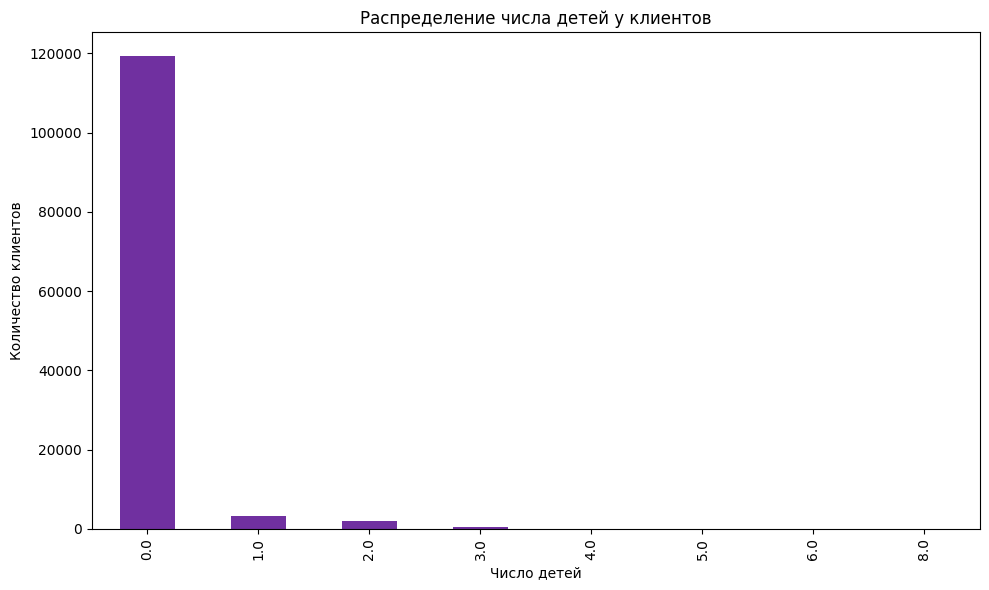

In [18]:
print("Распределение числа детей у клиентов:")
unique_clients = df[['client_rk', 'children_cnt']].drop_duplicates()
children_cnt = unique_clients['children_cnt'].value_counts()
total = children_cnt.sum()

for order_type, count in children_cnt.items():
    percentage = count / total * 100
    print(f"{order_type}: {count} ({percentage:.1f}%)")
    
plt.figure(figsize=(10, 6))
children_cnt.plot(kind='bar')
plt.title('Распределение числа детей у клиентов')
plt.xlabel('Число детей')
plt.ylabel('Количество клиентов')
plt.tight_layout()
plt.show()

**У подавляющего большинства покупателей (95.5%) нет детей.**

Возможно, следует сделать акцент на семейные предложения, например: 

1. предлагать популярные для семей направления, например, Турция, Египет;
2. партнерство с отелями, предлагающими услуги, развлечения для детей;
3. скидки и специальные предложения в периоды каникул.
 

In [51]:
print("\nРаспределение городов проживания клиентов:")
city_counts = df['lvn_city_nm'].value_counts().head(25)
total_clients = city_counts.sum()

for city, count in city_counts.items():
    percentage = count / total_clients * 100
    print(f"{city}: {count} ({percentage:.1f}%)")


Распределение городов проживания клиентов:
Г ЕКАТЕРИНБУРГ: 25609 (12.6%)
Г КАЗАНЬ: 16032 (7.9%)
Г УФА: 11476 (5.7%)
Г КРАСНОДАР: 9598 (4.7%)
Г ТЮМЕНЬ: 9594 (4.7%)
Г СОЧИ: 9592 (4.7%)
Г НОВОСИБИРСК: 9509 (4.7%)
Г ЧЕЛЯБИНСК: 9388 (4.6%)
Г САМАРА: 9363 (4.6%)
Г КРАСНОЯРСК: 8974 (4.4%)
Г ПЕРМЬ: 8603 (4.2%)
Г НИЖНИЙ НОВГОРОД: 7721 (3.8%)
Г КРАСНОГОРСК: 6941 (3.4%)
Г КАЛИНИНГРАД: 6464 (3.2%)
Г ХИМКИ: 6120 (3.0%)
Г ЛЮБЕРЦЫ: 5765 (2.8%)
Г ОМСК: 5711 (2.8%)
Г БАЛАШИХА: 5605 (2.8%)
Г СУРГУТ: 5212 (2.6%)
Г РОСТОВ-НА-ДОНУ: 4726 (2.3%)
Г МОСКВА: 4496 (2.2%)
Г САРАТОВ: 4341 (2.1%)
Г МЫТИЩИ: 4309 (2.1%)
Г ВОЛГОГРАД: 3890 (1.9%)
Г ВИДНОЕ: 3804 (1.9%)


**Странное наблюдение - Москва стоит на 21 месте, а Санкт-Петербурга и вовсе нет в рейтинге.** 

Ниже посчитано значение отдельно для Санкт-Петербурга.

Топ-3 городов: Екатеринбург, Казань и Уфа.

Данный рейтинг наводит на мысль о неполноте датасета.

In [57]:
spb_count = df['lvn_city_nm'].value_counts().get('Г САНКТ-ПЕТЕРБУРГ', 0)
print(f"Покупателей из Санкт-Петербурга: {spb_count}")

Покупателей из Санкт-Петербурга: 3004


In [59]:
print("\nРаспределение клиентов по гражданскому статусу:")
marital_status = df['marital_status_cd'].value_counts().head(25)
total_clients = marital_status.sum()

for status, count in marital_status.items():
    percentage = count / total_clients * 100
    print(f"{status}: {count} ({percentage:.1f}%)")


Распределение клиентов по гражданскому статусу:
MAR: 228349 (43.8%)
UNM: 220755 (42.4%)
CIV: 35362 (6.8%)
DIV: 34124 (6.6%)
WID: 2283 (0.4%)
DLW: 14 (0.0%)


**Первые 2 места в списке примерно поровну делят клиенты в браке и холостые.** Они составляют основную часть покупателей - 86.2%.

In [62]:
print("\nРаспределение клиентов по полу:")
gender = df['gender_cd'].value_counts().head(25)
total_clients = gender.sum()

for city, count in gender.items():
    percentage = count / total_clients * 100
    print(f"{city}: {count} ({percentage:.1f}%)")


Распределение клиентов по полу:
M: 519701 (62.9%)
F: 306079 (37.1%)



Распределение количества заказов пользователей:
1 заказ(ов): 53288 клиентов (35.9%)
5 заказ(ов): 14555 клиентов (9.8%)
4 заказ(ов): 11487 клиентов (7.7%)
6 заказ(ов): 11472 клиентов (7.7%)
3 заказ(ов): 8524 клиентов (5.7%)
7 заказ(ов): 8510 клиентов (5.7%)
8 заказ(ов): 6639 клиентов (4.5%)
2 заказ(ов): 6457 клиентов (4.4%)
9 заказ(ов): 4883 клиентов (3.3%)
10 заказ(ов): 3756 клиентов (2.5%)
11 заказ(ов): 3023 клиентов (2.0%)
12 заказ(ов): 2259 клиентов (1.5%)
13 заказ(ов): 1940 клиентов (1.3%)
14 заказ(ов): 1501 клиентов (1.0%)
15 заказ(ов): 1328 клиентов (0.9%)
16 заказ(ов): 1036 клиентов (0.7%)
17 заказ(ов): 915 клиентов (0.6%)
18 заказ(ов): 795 клиентов (0.5%)
19 заказ(ов): 639 клиентов (0.4%)
20 заказ(ов): 560 клиентов (0.4%)


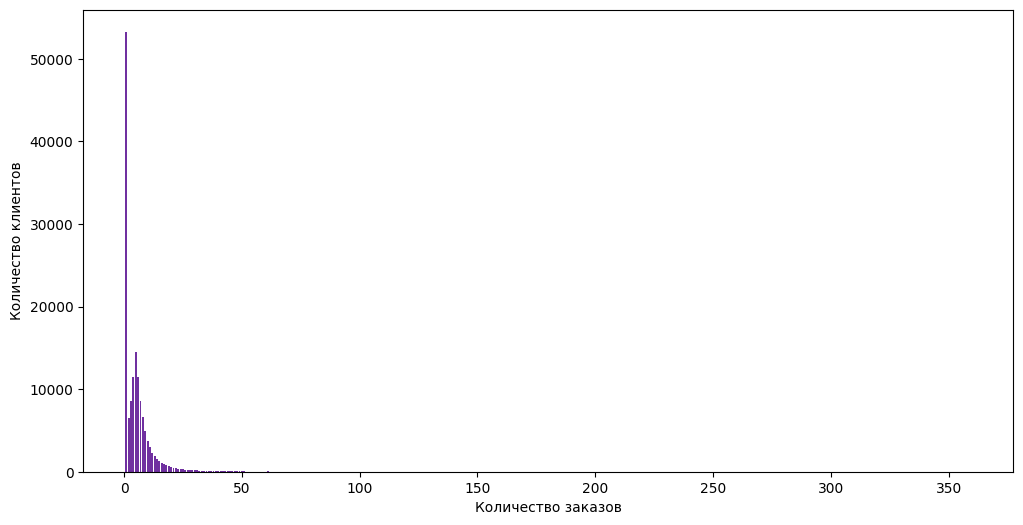

In [123]:
print("\nРаспределение количества заказов пользователей:")

orders_per_client = df.groupby('client_rk').size()
orders_cnt = orders_per_client.value_counts().sort_values(ascending=False)
total_clients = len(orders_per_client)

for i, (orders_count, client_count) in enumerate(orders_cnt.items()):
    if i >= 20:
        break
    percentage = client_count / total_clients * 100
    print(f"{orders_count} заказ(ов): {client_count} клиентов ({percentage:.1f}%)")


plt.figure(figsize=(12, 6))
plt.bar(orders_cnt.index, orders_cnt.values)
plt.xlabel('Количество заказов')
plt.ylabel('Количество клиентов')
plt.show()

Очевидно, больше всего клиентов, сделавших 1 заказ. Но также большое количество клиентов с 4-6 заказами.

Можно внедрить скидку на каждый третий-пятый заказ.

**Также создадим новую колонку с количеством заказов у каждого пользователя, чтобы посмотреть корреляцию с другими признаками:**

In [63]:
df['orders_per_client'] = df.groupby('client_rk')['client_rk'].transform('count')

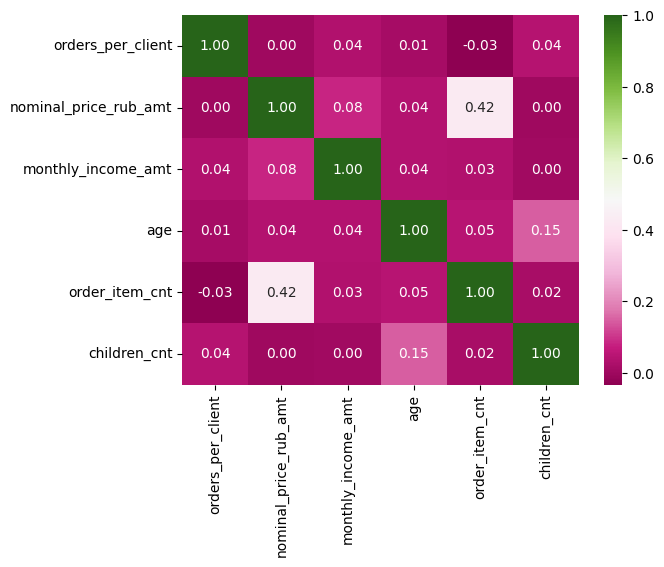

In [125]:
features = ['orders_per_client', 'nominal_price_rub_amt', 'monthly_income_amt', 'age', 'order_item_cnt', 'children_cnt']
corr_matrix = df[features].corr()

sns.heatmap(corr_matrix, annot=True, cmap='PiYG', fmt='.2f')
plt.show()

Значимой корреляции между признаками не наблюдается (не считая месячного дохода и количества позиций в заказе, но нас это не интересует).

**Посмотрим на распределение заказов по времени суток:**

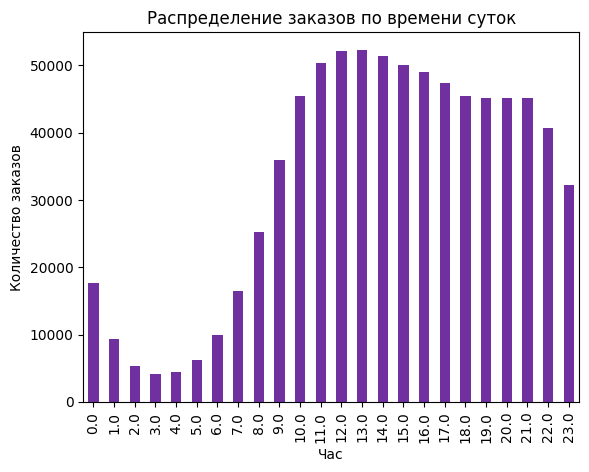

In [126]:
df['order_time'] = df['created_dttm'].dt.hour
df['order_time'].value_counts().sort_index().plot(kind='bar')
plt.title('Распределение заказов по времени суток')
plt.xlabel('Час')
plt.ylabel('Количество заказов')
plt.show()

Наиболее активно покупки совершаются днем с 12 до 15 часов. Можно усилить поддержку клиентов в это время. Также высокий спрос наблюдается вплоть до 10-11 часов вечера.

**И также по месяцам:**

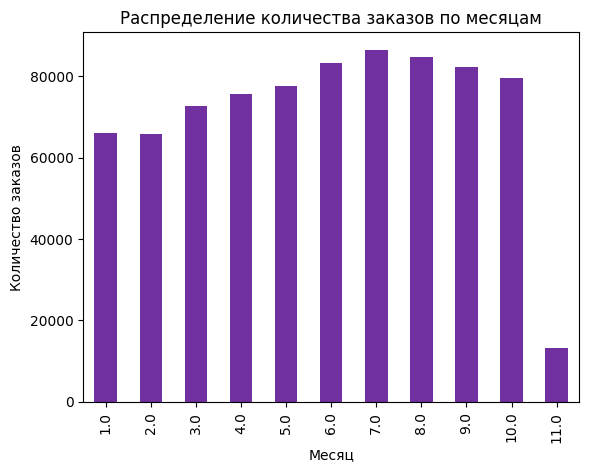

order_month
1.0     65932
2.0     65897
3.0     72580
4.0     75606
5.0     77554
6.0     83146
7.0     86484
8.0     84689
9.0     82220
10.0    79666
11.0    13111
Name: count, dtype: int64


In [21]:
df['order_month'] = df['created_dttm'].dt.month
df['order_month'].value_counts().sort_index().plot(kind='bar')
plt.title('Распределение количества заказов по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Количество заказов')
plt.show()

print(df['order_month'].value_counts().sort_index())

Пик заказов приходится на теплое время года: май-октябрь. Самый популярный месяц для путешествий - июль. В ноябре спрос резко падает, а в декабре заказы отсутствуют, откуда делаем вывод, что датасет неполный.

Идеи:
- повышать цены в период максимального спроса;
- предлагать промокоды, скидки в зимний период.

## Анализ доли сервиса Т-Банка в данной индустрии:

(большая часть выводов в презентации)

**Приблизительная оценка общей выручки:**

In [32]:
year_total_sales = df[df['created_dttm'].dt.month < 11]['nominal_price_rub_amt'].sum() / 10 * 12
year_total_sales

np.float64(14065518428.400002)

Доля Т-Банка приблизительно равна 1.73%.

**Отдельно для авиабилетов:**

https://www.rbc.ru/industries/news/68dbd1fb9a79470691cf8ed1: "По оценкам AnalyticResearchGroup, Россия занимает около 2% от всемирного рынка онлайн-продаж авиабилетов — это порядка $9,5 млрд".

На сегодняшний день это составляет 765.7 млрд долларов.

Доля Т-Банка в данной индустрии - 1.52%.

In [34]:
year_total_tickets_sales = df[(df['order_type_cd'] == 'AIR') & (df['created_dttm'].dt.month < 11)]['nominal_price_rub_amt'].sum() / 10 * 12
year_total_tickets_sales

np.float64(11652532128.0)

**Отдельно для отелей:**

In [24]:
total_hotel_sales = df[df['order_type_cd'] == 'HOT']['nominal_price_rub_amt'].sum()
total_hotel_sales

np.float64(2053197300.0)

In [33]:
year_total_hotel_sales = df[(df['order_type_cd'] == 'HOT') & (df['created_dttm'].dt.month < 11)]['nominal_price_rub_amt'].sum() / 10 * 12
year_total_hotel_sales

np.float64(2412986300.3999996)

По данным с сайта https://apelsin.tours/news/2741 доля сервиса «Островок» на рынке онлайн-бронирований по итогам 2024 года составила 21,5%, а совокупная выручка - 9,7 млрд рублей. Следовательно, общий оборот данного рынка в России составляет приблизительно 45,1 млрд рублей. 

Значит, доля Т-Банка - 5.35%.